In [80]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import torch
import pickle
from IPython.display import display
from vector_ptycho.utils import _to_numpy

device = "cuda" if torch.cuda.is_available() else "cpu"

from vector_ptycho.utils import *
from vector_ptycho.plotting_utils import *
from vector_ptycho.Neel_field_sim_utils import *
from vector_ptycho.reconstruction_utils import *

(3, 272, 272) (3, 272, 272)
Shape of normalisation arrays: (272, 272) (272, 272)


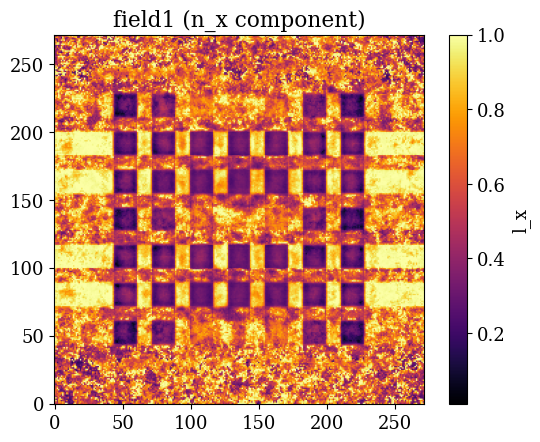

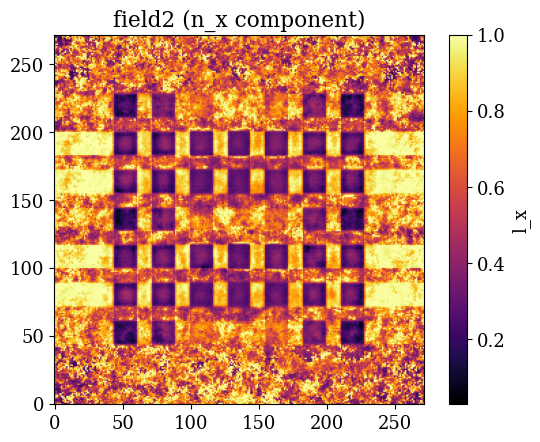

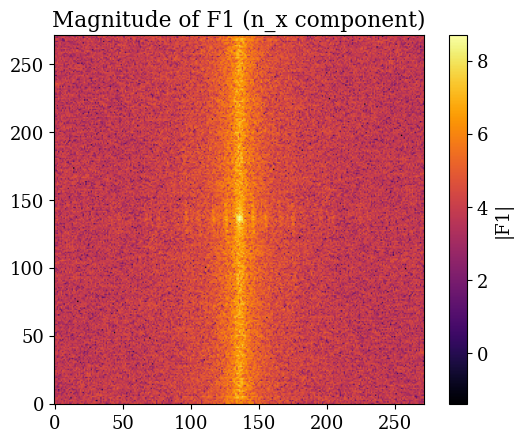

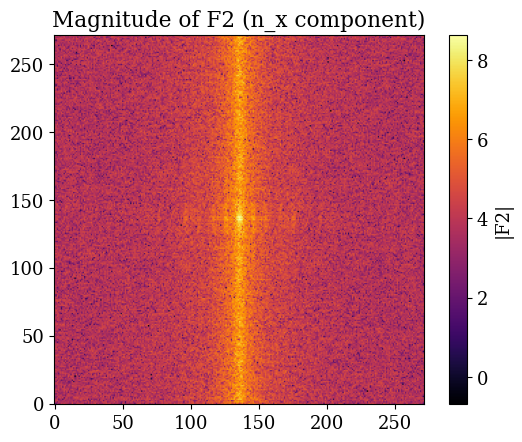

F1, F2 shapes: (3, 272, 272) (3, 272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (2

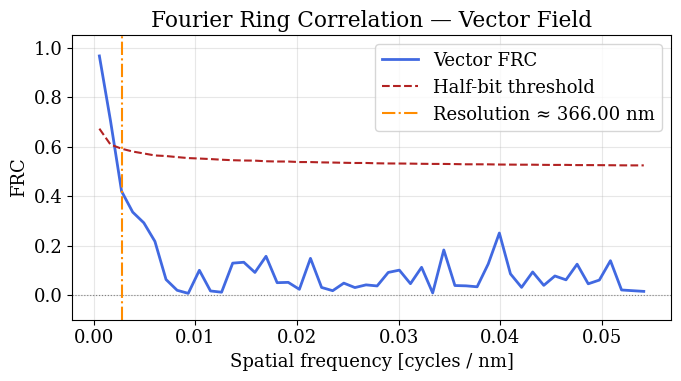

In [81]:

def vector_frc(field1: np.ndarray, field2: np.ndarray, pixel_size: float = 1.0):
    """
    Compute the Fourier Ring Correlation between two vector fields.

    Each field has shape (3, H, W)
    The vector dot product generalisation is used:

        FRC(q) = |sum_{q' in ring} F1(q') . F2*(q')| 
                 / sqrt(sum|F1|^2 * sum|F2|^2)

    where F1 . F2* = F1x*conj(F2x) + F1y*conj(F2y) + F1z*conj(F2z)

    Parameters
    ----------
    field1 : np.ndarray, shape (3, H, W)
        First vector field reconstruction.
    field2 : np.ndarray, shape (3, H, W)
        Second vector field reconstruction.
    pixel_size : float
        Physical size of each pixel (e.g. nm). Used to scale the frequency axis.
        Default 1.0 returns frequencies in units of cycles/pixel.

    Returns
    -------
    q_bins : np.ndarray, shape (n_bins,)
        Spatial frequency at the centre of each ring [cycles / pixel_size unit].
    frc : np.ndarray, shape (n_bins,)
        FRC value for each ring, in [0, 1].
    half_bit_threshold : np.ndarray, shape (n_bins,)
        Half-bit threshold as a function of ring occupancy.
    resolution : float
        Estimated resolution: 1 / q* where q* is the first crossing of the
        half-bit threshold. Units are the same as pixel_size.
    """
    field1 = np.array(_to_numpy(field1), copy=True)
    field2 = np.array(_to_numpy(field2), copy=True)

    C, H, W = field1.shape
    assert field2.shape == field1.shape, "Both fields must have the same shape"
    assert C == 3, "Last dimension must be 3 for [n_x, n_y, n_z]"

    def unwrap_director_field(lx, ly, lz):
        """
        Propagate a consistent gauge choice for a director field l ≡ -l
        using a flood-fill from a seed pixel.
        """
        shape = lx.shape
        field = np.stack([lx, ly, lz], axis=0)  # (3, ny, nx)
        fixed = np.zeros(shape, dtype=bool)
        result = field.copy()
        
        # Start from centre pixel
        seed = (shape[0]//2, shape[1]//2)
        fixed[seed] = True
        queue = [seed]
        
        while queue:
            i, j = queue.pop(0)
            ref = result[:, i, j]
            
            # Check 4-connected neighbours
            for di, dj in [(-1,0),(1,0),(0,-1),(0,1)]:
                ni, nj = i+di, j+dj
                if 0 <= ni < shape[0] and 0 <= nj < shape[1] and not fixed[ni, nj]:
                    neighbour = result[:, ni, nj]
                    # Flip neighbour if it points more anti-parallel than parallel
                    if np.dot(ref, neighbour) < 0:
                        result[:, ni, nj] = -neighbour
                    fixed[ni, nj] = True
                    queue.append((ni, nj))
        
        return result[0], result[1], result[2]

    field1[0], field1[1], field1[2] = unwrap_director_field(field1[0], field1[1], field1[2])
    field2[0], field2[1], field2[2] = unwrap_director_field(field2[0], field2[1], field2[2])

    # Normalise fields to unit length (director fields)
    norm1 = np.linalg.norm(field1, axis=0) + 1e-10
    norm2 = np.linalg.norm(field2, axis=0) + 1e-10
    print('Shape of normalisation arrays:', np.shape(norm1), np.shape(norm2))
    field1 /= norm1
    field2 /= norm2
    F1 = np.fft.fft2(field1, axes=(1, 2))
    F2 = np.fft.fft2(field2, axes=(1, 2))

    # Shift zero frequency to centre
    F1 = np.fft.fftshift(F1, axes=(1, 2))
    F2 = np.fft.fftshift(F2, axes=(1, 2))

    axis = 0
    plt.imshow(np.abs(field1[axis,:,:]), origin="lower", cmap="inferno")
    plt.title("field1 (n_x component)")
    plt.colorbar(label="l_x")
    plt.show()

    plt.imshow(np.abs(field2[axis,:,:]), origin="lower", cmap="inferno")
    plt.title("field2 (n_x component)")
    plt.colorbar(label="l_x")
    plt.show()

    plt.imshow(np.log(np.abs(F1[axis,:,:]) + 1e-10), origin="lower", cmap="inferno")
    plt.title("Magnitude of F1 (n_x component)")
    plt.colorbar(label="|F1|")
    plt.show()

    plt.imshow(np.log(np.abs(F2[axis,:,:]) + 1e-10), origin="lower", cmap="inferno")
    plt.title("Magnitude of F2 (n_x component)")
    plt.colorbar(label="|F2|")
    plt.show()

    print("F1, F2 shapes:", F1.shape, F2.shape)

    # --- Build radial frequency grid ---
    cy, cx = H // 2, W // 2
    fy = (np.arange(H) - cy) / (H * pixel_size)  # cycles per unit length
    fx = (np.arange(W) - cx) / (W * pixel_size)
    Fx, Fy = np.meshgrid(fx, fy)
    R = np.sqrt(Fx**2 + Fy**2)  # (H, W) radial frequency map

    # Maximum useful frequency: Nyquist
    q_nyquist = 0.5 / pixel_size
    #n_bins = min(H, W) // 2
    n_bins = 50
    # Bin edges and centres
    bin_edges = np.linspace(0, q_nyquist, n_bins + 1)
    q_bins = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    frc = np.zeros(n_bins)
    n_pixels = np.zeros(n_bins, dtype=int)

    for i in range(n_bins):
        mask = (R >= bin_edges[i]) & (R < bin_edges[i + 1])  # (H, W) bool

        #plt.imshow(mask.astype(float), origin="lower", cmap="gray")
        #plt.show()
        print("Mask shape:", mask.shape)
        n_pixels[i] = mask.sum()

        if n_pixels[i] == 0:
            continue

        # Extract pixels in this ring for all 3 components: shape (n_pix, 3)
        f1_ring = F1[:,mask]   # (n_pix, 3)
        f2_ring = F2[:,mask]   # (n_pix, 3)

        # Vector dot product: sum over pixels and components
        # numerator: |sum_pixels ( F1 . conj(F2) )|
        dot = np.sum(f1_ring * np.conj(f2_ring))          # scalar complex
        numerator = np.abs(dot)

        # Denominator: sqrt( sum|F1|^2 * sum|F2|^2 )
        # |F|^2 for a vector: sum over components
        power1 = np.sum(np.abs(f1_ring)**2)               # scalar real
        power2 = np.sum(np.abs(f2_ring)**2)               # scalar real
        denominator = np.sqrt(power1 * power2)

        if denominator > 0:
            frc[i] = numerator / denominator

    # --- Half-bit threshold ---
    # T(q) = (0.5 + 2.4142 / sqrt(n_q)) / (1 + 2.4142 / sqrt(n_q))
    with np.errstate(divide='ignore', invalid='ignore'):
        sqrt_n = np.sqrt(n_pixels.astype(float))
        half_bit_threshold = np.where(
            n_pixels > 0,
            (0.5 + 2.4142 / sqrt_n) / (1.0 + 2.4142 / sqrt_n),
            np.nan
        )

    # --- Find resolution: first crossing of half-bit threshold ---
    crossings = np.where(frc < half_bit_threshold)[0]
    if len(crossings) > 0:
        q_star = q_bins[crossings[0]]
        resolution = 1.0 / q_star if q_star > 0 else np.inf
    else:
        q_star = None
        resolution = np.inf
        print("Warning: FRC never crosses the half-bit threshold. "
              "Resolution may be limited by pixel size.")

    return q_bins, frc, half_bit_threshold, resolution


def plot_frc(q_bins, frc, half_bit_threshold, resolution, pixel_size_label="px"):
    """Plot the FRC curve with the half-bit threshold and resolution estimate."""
    fig, ax = plt.subplots(figsize=(7, 4))

    ax.plot(q_bins, frc, color="royalblue", lw=2, label="Vector FRC")
    ax.plot(q_bins, half_bit_threshold, color="firebrick", lw=1.5,
            linestyle="--", label="Half-bit threshold")
    ax.axhline(0, color="grey", lw=0.8, linestyle=":")

    if resolution < np.inf:
        ax.axvline(1.0 / resolution, color="darkorange", lw=1.5,
                   linestyle="-.", label=f"Resolution ≈ {resolution:.2f} {pixel_size_label}")

    ax.set_xlabel(f"Spatial frequency [cycles / {pixel_size_label}]")
    ax.set_ylabel("FRC")
    ax.set_title("Fourier Ring Correlation — Vector Field")
    ax.set_ylim(-0.1, 1.05)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig


if __name__ == "__main__":
    '''
    rng1 = np.random.default_rng(seed=42)
    rng2 = np.random.default_rng(seed=99)

    H, W = 256, 256
    pixel_size = 1.0  # nm (example)

    # Ground truth: a smooth director field (e.g. a skyrmion-like texture)
    y, x = np.mgrid[-H//2:H//2, -W//2:W//2].astype(float)
    r = np.sqrt(x**2 + y**2)
    phi = np.arctan2(y, x)
    theta = np.pi * np.exp(-r**2 / (0.1 * H)**2)  # radial profile

    n_x = np.sin(theta) * np.cos(phi)
    n_y = np.sin(theta) * np.sin(phi)
    n_z = np.cos(theta)
    ground_truth = np.stack([n_x, n_y, n_z], axis=-1)  # (H, W, 3)

    # Simulate two independent noisy realisations
    noise_level = 0.00005
    field1 = ground_truth + rng1.normal(0, noise_level, ground_truth.shape)
    field2 = ground_truth + rng2.normal(0, noise_level, ground_truth.shape)
    '''
    pixel_size = 9.15  # nm (example)
    ckpt_rnd_seed0 = torch.load(r'.\Successfull fluence run 03_06_2026 RndSeed 0\fluence_1e12\recon_post_STXM_10.pt')
    field1 = _to_numpy(ckpt_rnd_seed0['l'])
    ckpt_rnd_seed5 = torch.load(r'.\Successfull fluence run 04_06_2026 RndSeed 5\fluence_1e12\recon_post_STXM_10.pt')
    field2 = _to_numpy(ckpt_rnd_seed5['l'])
    crop_size = 120
    field1 = field1[:, crop_size:-crop_size, crop_size:-crop_size]
    field2 = field2[:, crop_size:-crop_size, crop_size:-crop_size]
    print(field1.shape, field2.shape)
    # Renormalise to unit vectors (as you would after ptychographic reconstruction)
    field1 /= np.linalg.norm(field1, axis=-1, keepdims=True)
    field2 /= np.linalg.norm(field2, axis=-1, keepdims=True)

    q_bins, frc, half_bit, resolution = vector_frc(field1, field2, pixel_size=pixel_size)

    print(f"Estimated resolution: {resolution:.2f} nm")

    fig = plot_frc(q_bins, frc, half_bit, resolution, pixel_size_label="nm")
    plt.show()


Field shapes: (3, 272, 272) (3, 272, 272)
Tracelessness check — max |tr(Q1)|: 2.00e-10  max |tr(Q2)|: 2.00e-10  (should be ~0)


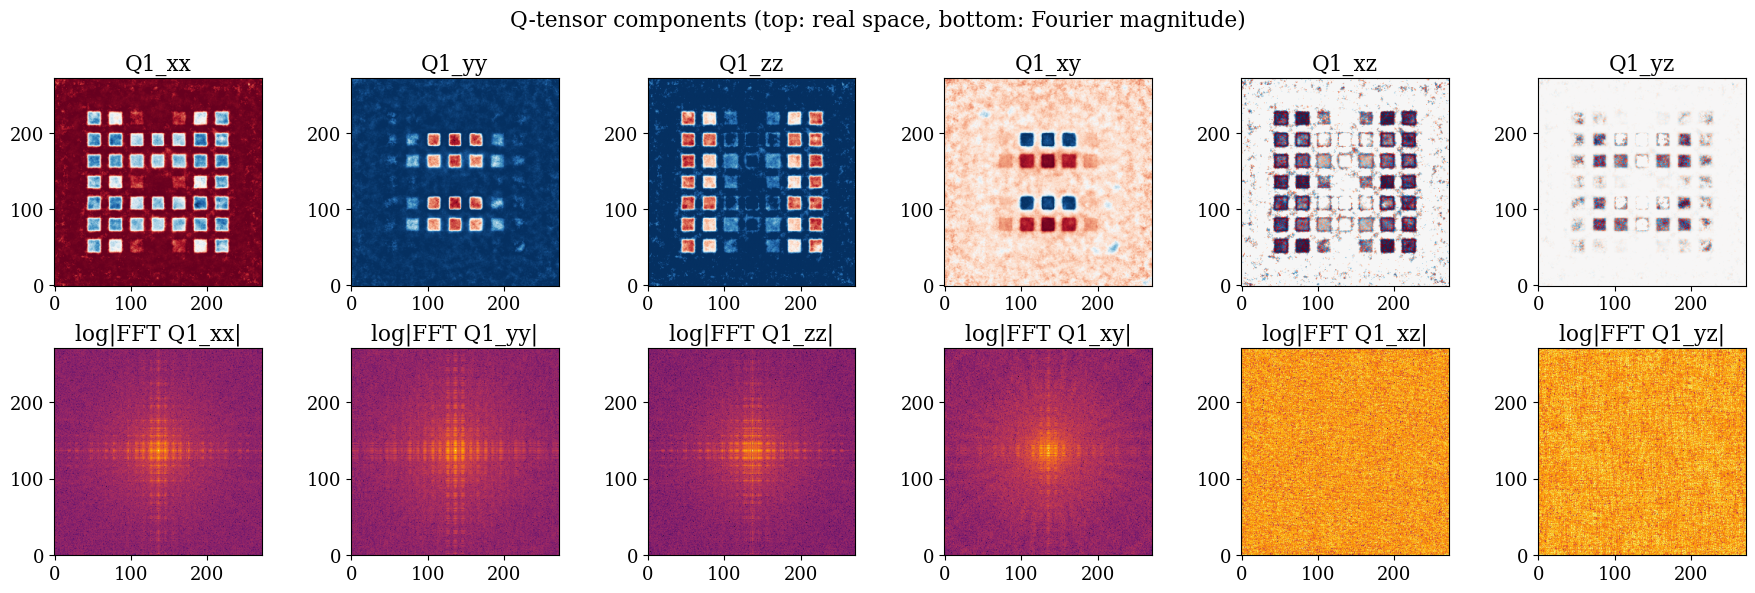

Estimated resolution: 66.55 nm


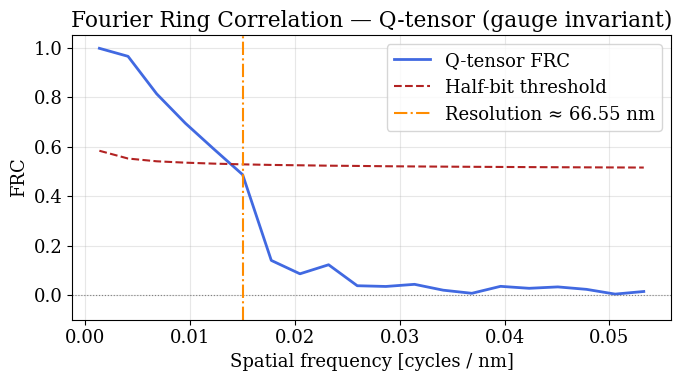

In [82]:
import numpy as np
import matplotlib.pyplot as plt
import torch


def _to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.array(x)


def director_to_qtensor(field: np.ndarray) -> dict:
    """
    Convert a unit director field to its Q-tensor representation.

    The Q-tensor is defined as:

        Q_ij = l_i * l_j - (1/3) * delta_ij

    Written out explicitly as a 3x3 symmetric matrix:

        Q = | l_x*l_x - 1/3    l_x*l_y          l_x*l_z        |
            | l_y*l_x          l_y*l_y - 1/3    l_y*l_z        |
            | l_z*l_x          l_z*l_y          l_z*l_z - 1/3  |

    Key properties:
        - Symmetric:  Q_ij = Q_ji
        - Traceless:  Q_xx + Q_yy + Q_zz = 0  (because |l|^2 = 1)
        - Gauge invariant: Q(-l) = Q(l)  (the l -> -l ambiguity vanishes)

    Because Q is symmetric, it has 6 potentially independent components.
    Tracelessness removes one more degree of freedom, leaving 5 independent
    components. However, here we store all 6 upper-triangle components
    explicitly (including Q_zz) for clarity. The redundancy Q_zz = -Q_xx - Q_yy
    is verified as a sanity check.

    Parameters
    ----------
    field : np.ndarray, shape (3, H, W)
        Unit director field with components [lx, ly, lz] along axis 0.

    Returns
    -------
    Q : dict
        Dictionary with keys 'xx', 'yy', 'zz', 'xy', 'xz', 'yz',
        each a real-valued array of shape (H, W).
    """
    lx = field[0]   # shape (H, W)
    ly = field[1]   # shape (H, W)
    lz = field[2]   # shape (H, W)

    # --- Diagonal components ---
    Q_xx = lx * lx - 1.0 / 3.0
    Q_yy = ly * ly - 1.0 / 3.0
    Q_zz = lz * lz - 1.0 / 3.0
    # Tracelessness check: Q_xx + Q_yy + Q_zz = |l|^2 - 1 = 0 for unit vectors

    # --- Off-diagonal components (appear twice in full 3x3 matrix by symmetry) ---
    Q_xy = lx * ly   # = Q_yx
    Q_xz = lx * lz   # = Q_zx
    Q_yz = ly * lz   # = Q_zy

    return {
        'xx': Q_xx,
        'yy': Q_yy,
        'zz': Q_zz,
        'xy': Q_xy,
        'xz': Q_xz,
        'yz': Q_yz,
    }


def frobenius_inner_product(A: dict, B: dict) -> complex:
    """
    Compute the Frobenius inner product of two Q-tensors summed over all
    pixels in a ring:

        <A, B>_F = sum_pixels sum_{i,j} A_ij * conj(B_ij)

    For a symmetric tensor this expands to:
        = sum_pixels [   A_xx * conj(B_xx)
                       + A_yy * conj(B_yy)
                       + A_zz * conj(B_zz)
                       + 2 * A_xy * conj(B_xy)   <- factor 2 from Q_xy = Q_yx
                       + 2 * A_xz * conj(B_xz)   <- factor 2 from Q_xz = Q_zx
                       + 2 * A_yz * conj(B_yz) ] <- factor 2 from Q_yz = Q_zy

    Parameters
    ----------
    A, B : dict
        Q-tensor component dictionaries with keys 'xx','yy','zz','xy','xz','yz'.
        Values are complex arrays of shape (n_pixels,) — the ring pixels.

    Returns
    -------
    inner : complex scalar
    """
    # Diagonal terms (each appears once in the sum over all 9 tensor elements)
    term_xx = np.sum(A['xx'] * np.conj(B['xx']))
    term_yy = np.sum(A['yy'] * np.conj(B['yy']))
    term_zz = np.sum(A['zz'] * np.conj(B['zz']))

    # Off-diagonal terms (each appears twice: Q_xy and Q_yx are equal)
    term_xy = 2.0 * np.sum(A['xy'] * np.conj(B['xy']))
    term_xz = 2.0 * np.sum(A['xz'] * np.conj(B['xz']))
    term_yz = 2.0 * np.sum(A['yz'] * np.conj(B['yz']))

    return term_xx + term_yy + term_zz + term_xy + term_xz + term_yz


def frobenius_norm_sq(A: dict) -> float:
    """
    Frobenius norm squared of a Q-tensor, summed over all pixels in a ring:

        ||A||^2_F = <A, A>_F
                  = sum_pixels [   A_xx^2 + A_yy^2 + A_zz^2
                                 + 2*A_xy^2 + 2*A_xz^2 + 2*A_yz^2 ]

    Returns a real scalar (imaginary part is zero by construction).
    """
    term_xx = np.sum(np.abs(A['xx'])**2)
    term_yy = np.sum(np.abs(A['yy'])**2)
    term_zz = np.sum(np.abs(A['zz'])**2)

    term_xy = 2.0 * np.sum(np.abs(A['xy'])**2)
    term_xz = 2.0 * np.sum(np.abs(A['xz'])**2)
    term_yz = 2.0 * np.sum(np.abs(A['yz'])**2)

    return np.real(term_xx + term_yy + term_zz + term_xy + term_xz + term_yz)


def fft_qtensor(Q: dict) -> dict:
    """
    Compute the 2D FFT of each Q-tensor component independently,
    then shift the zero frequency to the centre.

    Parameters
    ----------
    Q : dict
        Real-space Q-tensor with keys 'xx','yy','zz','xy','xz','yz',
        each of shape (H, W).

    Returns
    -------
    FQ : dict
        Fourier-space Q-tensor with the same keys, each of shape (H, W),
        complex valued.
    """
    FQ = {}
    for key, component in Q.items():
        FQ[key] = np.fft.fftshift(np.fft.fft2(component))
    return FQ


def extract_ring(FQ: dict, mask: np.ndarray) -> dict:
    """
    Extract the pixels within a Fourier ring for each Q-tensor component.

    Parameters
    ----------
    FQ : dict
        Fourier-space Q-tensor, each component of shape (H, W).
    mask : np.ndarray, shape (H, W), bool
        True for pixels inside the ring.

    Returns
    -------
    ring : dict
        Each component is now a 1D complex array of shape (n_pixels,).
    """
    return {key: FQ[key][mask] for key in FQ}


def vector_frc(field1: np.ndarray, field2: np.ndarray, pixel_size: float = 1.0, plot_diagnostics: bool = True):
    """
    Compute the Fourier Ring Correlation between two Neel director fields
    using the Q-tensor representation.

    The Q-tensor Q_ij = l_i l_j - (1/3) delta_ij is gauge-invariant under
    l -> -l, so no phase unwrapping or flood-fill gauge fixing is needed.
    This makes it the natural object to Fourier transform for a director field.

    The FRC is defined via the Frobenius inner product on the Q-tensors:

        FRC(q) = | sum_{q' in ring} <FQ1(q'), FQ2(q')>_F |
                 / sqrt( ||FQ1||^2_F * ||FQ2||^2_F )

    where the Frobenius inner product sums over all 9 tensor components
    (with off-diagonal components counted twice due to symmetry).

    Parameters
    ----------
    field1 : np.ndarray, shape (3, H, W)
        First director field reconstruction [lx, ly, lz].
    field2 : np.ndarray, shape (3, H, W)
        Second director field reconstruction [lx, ly, lz].
    pixel_size : float
        Physical size of each pixel (e.g. nm).

    Returns
    -------
    q_bins : np.ndarray, shape (n_bins,)
        Spatial frequency at centre of each ring [cycles / pixel_size unit].
    frc : np.ndarray, shape (n_bins,)
        FRC value for each ring, in [0, 1].
    half_bit_threshold : np.ndarray, shape (n_bins,)
        Half-bit threshold curve as a function of ring occupancy n_r:
            T(q) = (0.5 + 2.4142/sqrt(n_r)) / (1.0 + 2.4142/sqrt(n_r))
    resolution : float
        Estimated resolution 1/q* where q* is the first crossing of the
        half-bit threshold. Units match pixel_size.
    """
    field1 = np.array(_to_numpy(field1), dtype=float, copy=True)
    field2 = np.array(_to_numpy(field2), dtype=float, copy=True)

    C, H, W = field1.shape
    assert field2.shape == field1.shape, "Both fields must have the same shape"
    assert C == 3, "Field must have shape (3, H, W) for [lx, ly, lz]"

    # --- Step 1: Normalise to unit vectors ---
    norm1 = np.linalg.norm(field1, axis=0, keepdims=True) + 1e-10
    norm2 = np.linalg.norm(field2, axis=0, keepdims=True) + 1e-10
    field1 /= norm1
    field2 /= norm2

    # --- Step 2: Convert to Q-tensor ---
    # Each Q is a dict with keys 'xx','yy','zz','xy','xz','yz', shape (H, W)
    # This is the step that removes the l -> -l gauge ambiguity.
    Q1 = director_to_qtensor(field1)
    Q2 = director_to_qtensor(field2)

    # Sanity check: verify tracelessness (should be ~0 everywhere)
    trace1 = Q1['xx'] + Q1['yy'] + Q1['zz']
    trace2 = Q2['xx'] + Q2['yy'] + Q2['zz']
    print(f"Tracelessness check — max |tr(Q1)|: {np.max(np.abs(trace1)):.2e}  "
          f"max |tr(Q2)|: {np.max(np.abs(trace2)):.2e}  (should be ~0)")

    # --- Step 3: FFT each Q-tensor component ---
    # FQ1, FQ2 are dicts with same keys, now complex valued, shape (H, W)
    FQ1 = fft_qtensor(Q1)
    FQ2 = fft_qtensor(Q2)

    if plot_diagnostics:
        # --- Diagnostic plots: real-space Q and its Fourier magnitude ---
        fig, axes = plt.subplots(2, 6, figsize=(18, 6))
        comp_names = ['xx', 'yy', 'zz', 'xy', 'xz', 'yz']
        for k, key in enumerate(comp_names):
            axes[0, k].imshow(Q1[key], origin='lower', cmap='RdBu_r')
            axes[0, k].set_title(f'Q1_{key}')
            axes[1, k].imshow(np.log(np.abs(FQ1[key]) + 1e-10), origin='lower', cmap='inferno')
            axes[1, k].set_title(f'log|FFT Q1_{key}|')
        plt.suptitle('Q-tensor components (top: real space, bottom: Fourier magnitude)')
        plt.tight_layout()
        plt.show()

    # --- Step 4: Build radial frequency grid ---
    cy, cx = H // 2, W // 2
    fy = (np.arange(H) - cy) / (H * pixel_size)   # cycles per unit length
    fx = (np.arange(W) - cx) / (W * pixel_size)
    Fx, Fy = np.meshgrid(fx, fy)
    R = np.sqrt(Fx**2 + Fy**2)                     # radial frequency, shape (H, W)

    q_nyquist = 0.5 / pixel_size
    n_bins = 20
    bin_edges = np.linspace(0, q_nyquist, n_bins + 1)
    q_bins = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    frc      = np.zeros(n_bins)
    n_pixels = np.zeros(n_bins, dtype=int)

    # --- Step 5: Compute FRC ring by ring ---
    for i in range(n_bins):
        mask = (R >= bin_edges[i]) & (R < bin_edges[i + 1])   # shape (H, W) bool
        n_pixels[i] = mask.sum()

        if n_pixels[i] == 0:
            continue

        # Extract ring pixels for every Q-tensor component
        # Each value in fq1_ring / fq2_ring is a 1D complex array of length n_pixels[i]
        fq1_ring = extract_ring(FQ1, mask)
        fq2_ring = extract_ring(FQ2, mask)

        # Frobenius inner product summed over the ring
        numerator   = np.abs(frobenius_inner_product(fq1_ring, fq2_ring))

        # Frobenius norm squared of each field in the ring
        power1      = frobenius_norm_sq(fq1_ring)
        power2      = frobenius_norm_sq(fq2_ring)
        denominator = np.sqrt(power1 * power2)

        if denominator > 0:
            frc[i] = numerator / denominator

    # --- Step 6: Half-bit threshold ---
    # T(q) = (0.5 + 2.4142/sqrt(n_r)) / (1.0 + 2.4142/sqrt(n_r))
    # Derived from requiring >= 0.5 bits of Shannon information per Fourier pixel.
    # The constants 2.4142 = 1 + sqrt(2) arise from the statistical correction
    # for finite ring sample size.
    with np.errstate(divide='ignore', invalid='ignore'):
        sqrt_n = np.sqrt(n_pixels.astype(float))
        half_bit_threshold = np.where(
            n_pixels > 0,
            (0.5 + 2.4142 / sqrt_n) / (1.0 + 2.4142 / sqrt_n),
            np.nan
        )

    # --- Step 7: Resolution estimate ---
    # Find first q where FRC drops below the half-bit threshold
    crossings = np.where(frc < half_bit_threshold)[0]
    if len(crossings) > 0:
        q_star     = q_bins[crossings[0]]
        resolution = 1.0 / q_star if q_star > 0 else np.inf
    else:
        resolution = np.inf
        print("Warning: FRC never crosses the half-bit threshold. "
              "Resolution may be limited by pixel size.")

    return q_bins, frc, half_bit_threshold, resolution


def plot_frc(q_bins, frc, half_bit_threshold, resolution, pixel_size_label="px"):
    """Plot the FRC curve with the half-bit threshold and resolution estimate."""
    fig, ax = plt.subplots(figsize=(7, 4))

    ax.plot(q_bins, frc, color="royalblue", lw=2, label="Q-tensor FRC")
    ax.plot(q_bins, half_bit_threshold, color="firebrick", lw=1.5,
            linestyle="--", label="Half-bit threshold")
    ax.axhline(0, color="grey", lw=0.8, linestyle=":")

    if resolution < np.inf:
        ax.axvline(1.0 / resolution, color="darkorange", lw=1.5,
                   linestyle="-.",
                   label=f"Resolution ≈ {resolution:.2f} {pixel_size_label}")

    ax.set_xlabel(f"Spatial frequency [cycles / {pixel_size_label}]")
    ax.set_ylabel("FRC")
    ax.set_title("Fourier Ring Correlation — Q-tensor (gauge invariant)")
    ax.set_ylim(-0.1, 1.05)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig


if __name__ == "__main__":
    pixel_size = 9.15  # nm

    ckpt_rnd_seed0 = torch.load(
        r'.\Successfull fluence run 03_06_2026 RndSeed 0\fluence_1e11\recon_post_STXM_10.pt'
    )
    field1 = _to_numpy(ckpt_rnd_seed0['l'])

    ckpt_rnd_seed5 = torch.load(
        r'.\Successfull fluence run 04_06_2026 RndSeed 5\fluence_1e11\recon_post_STXM_10.pt'
    )
    field2 = _to_numpy(ckpt_rnd_seed5['l'])

    crop_size = 120
    field1 = field1[:, crop_size:-crop_size, crop_size:-crop_size]
    field2 = field2[:, crop_size:-crop_size, crop_size:-crop_size]
    print("Field shapes:", field1.shape, field2.shape)

    # Normalise to unit vectors
    field1 /= np.linalg.norm(field1, axis=0, keepdims=True)
    field2 /= np.linalg.norm(field2, axis=0, keepdims=True)

    q_bins, frc, half_bit, resolution = vector_frc(field1, field2, pixel_size=pixel_size)

    print(f"Estimated resolution: {resolution:.2f} nm")

    fig = plot_frc(q_bins, frc, half_bit, resolution, pixel_size_label="nm")
    plt.show()

Field shapes: (3, 272, 272) (3, 272, 272)
Tracelessness check — max |tr(Q1)|: 2.00e-10  max |tr(Q2)|: 2.00e-10  (should be ~0)


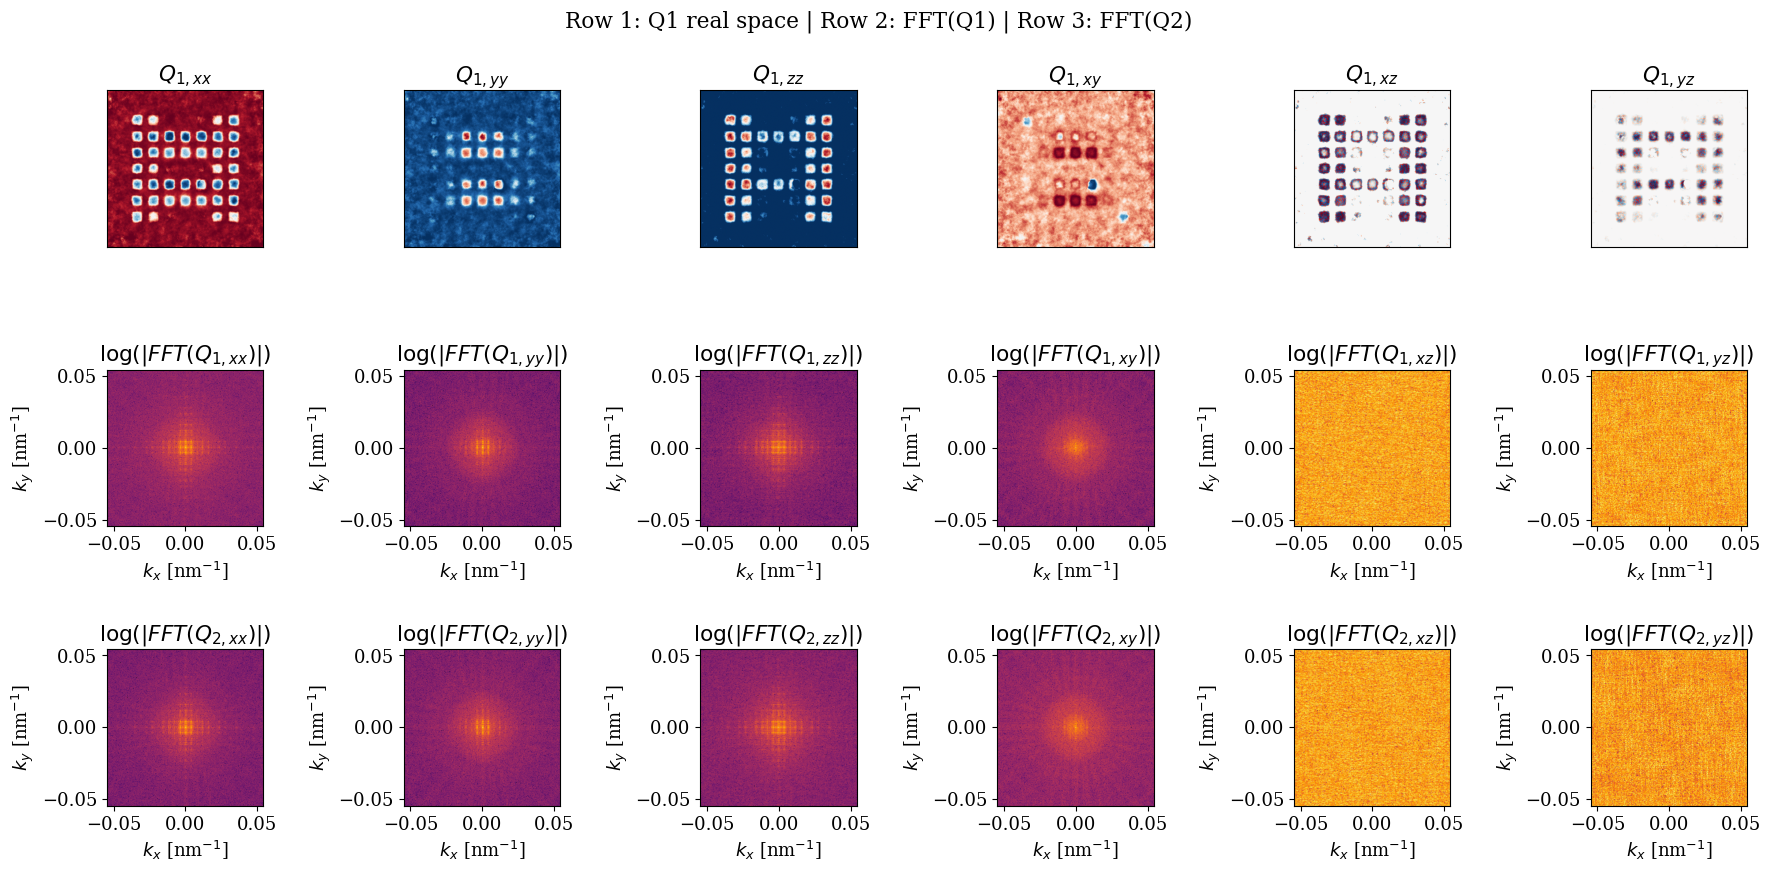

Estimated resolution: 80.52 nm


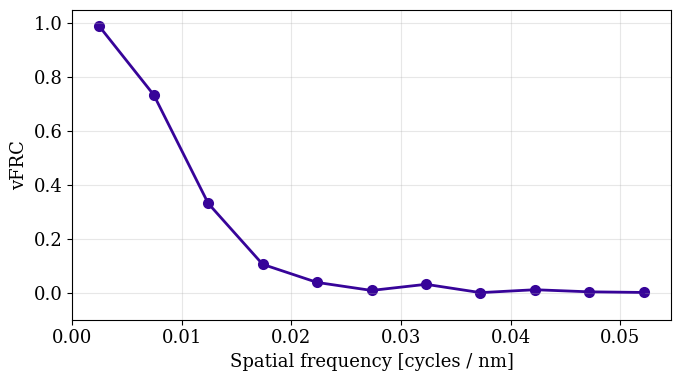

In [94]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import torch

# Plasma colour scheme
light_yellow = '#ffb82e'
pinky = '#cf4c73'
light_purple = '#8204a7'
dark_purple = '#370499'


def _to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.array(x)


def director_to_qtensor(field: np.ndarray) -> dict:
    """
    Convert a unit director field to its Q-tensor representation.

    The Q-tensor is defined as:

        Q_ij = l_i * l_j - (1/3) * delta_ij

    Written out explicitly as a 3x3 symmetric matrix:

        Q = | l_x*l_x - 1/3    l_x*l_y          l_x*l_z        |
            | l_y*l_x          l_y*l_y - 1/3    l_y*l_z        |
            | l_z*l_x          l_z*l_y          l_z*l_z - 1/3  |

    Key properties:
        - Symmetric:  Q_ij = Q_ji
        - Traceless:  Q_xx + Q_yy + Q_zz = 0  (because |l|^2 = 1)
        - Gauge invariant: Q(-l) = Q(l)  (the l -> -l ambiguity vanishes)

    Because Q is symmetric, it has 6 potentially independent components.
    Tracelessness removes one more degree of freedom, leaving 5 independent
    components. However, here we store all 6 upper-triangle components
    explicitly (including Q_zz) for clarity. The redundancy Q_zz = -Q_xx - Q_yy
    is verified as a sanity check.

    Parameters
    ----------
    field : np.ndarray, shape (3, H, W)
        Unit director field with components [lx, ly, lz] along axis 0.

    Returns
    -------
    Q : dict
        Dictionary with keys 'xx', 'yy', 'zz', 'xy', 'xz', 'yz',
        each a real-valued array of shape (H, W).
    """
    lx = field[0]   # shape (H, W)
    ly = field[1]   # shape (H, W)
    lz = field[2]   # shape (H, W)

    # --- Diagonal components ---
    Q_xx = lx * lx - 1.0 / 3.0
    Q_yy = ly * ly - 1.0 / 3.0
    Q_zz = lz * lz - 1.0 / 3.0
    # Tracelessness check: Q_xx + Q_yy + Q_zz = |l|^2 - 1 = 0 for unit vectors

    # --- Off-diagonal components (appear twice in full 3x3 matrix by symmetry) ---
    Q_xy = lx * ly   # = Q_yx
    Q_xz = lx * lz   # = Q_zx
    Q_yz = ly * lz   # = Q_zy

    return {
        'xx': Q_xx,
        'yy': Q_yy,
        'zz': Q_zz,
        'xy': Q_xy,
        'xz': Q_xz,
        'yz': Q_yz,
    }


def frobenius_inner_product(A: dict, B: dict) -> complex:
    """
    Compute the Frobenius inner product of two Q-tensors summed over all
    pixels in a ring:

        <A, B>_F = sum_pixels sum_{i,j} A_ij * conj(B_ij)

    For a symmetric tensor this expands to:
        = sum_pixels [   A_xx * conj(B_xx)
                       + A_yy * conj(B_yy)
                       + A_zz * conj(B_zz)
                       + 2 * A_xy * conj(B_xy)   <- factor 2 from Q_xy = Q_yx
                       + 2 * A_xz * conj(B_xz)   <- factor 2 from Q_xz = Q_zx
                       + 2 * A_yz * conj(B_yz) ] <- factor 2 from Q_yz = Q_zy

    Parameters
    ----------
    A, B : dict
        Q-tensor component dictionaries with keys 'xx','yy','zz','xy','xz','yz'.
        Values are complex arrays of shape (n_pixels,) — the ring pixels.

    Returns
    -------
    inner : complex scalar
    """
    # Diagonal terms (each appears once in the sum over all 9 tensor elements)
    term_xx = np.sum(A['xx'] * np.conj(B['xx']))
    term_yy = np.sum(A['yy'] * np.conj(B['yy']))
    term_zz = np.sum(A['zz'] * np.conj(B['zz']))

    # Off-diagonal terms (each appears twice: Q_xy and Q_yx are equal)
    term_xy = 2.0 * np.sum(A['xy'] * np.conj(B['xy']))
    term_xz = 2.0 * np.sum(A['xz'] * np.conj(B['xz']))
    term_yz = 2.0 * np.sum(A['yz'] * np.conj(B['yz']))

    return term_xx + term_yy + term_zz + term_xy + term_xz + term_yz


def frobenius_norm_sq(A: dict) -> float:
    """
    Frobenius norm squared of a Q-tensor, summed over all pixels in a ring:

        ||A||^2_F = <A, A>_F
                  = sum_pixels [   A_xx^2 + A_yy^2 + A_zz^2
                                 + 2*A_xy^2 + 2*A_xz^2 + 2*A_yz^2 ]

    Returns a real scalar (imaginary part is zero by construction).
    """
    term_xx = np.sum(np.abs(A['xx'])**2)
    term_yy = np.sum(np.abs(A['yy'])**2)
    term_zz = np.sum(np.abs(A['zz'])**2)

    term_xy = 2.0 * np.sum(np.abs(A['xy'])**2)
    term_xz = 2.0 * np.sum(np.abs(A['xz'])**2)
    term_yz = 2.0 * np.sum(np.abs(A['yz'])**2)

    return np.real(term_xx + term_yy + term_zz + term_xy + term_xz + term_yz)


def fft_qtensor(Q: dict) -> dict:
    """
    Compute the 2D FFT of each Q-tensor component independently,
    then shift the zero frequency to the centre.

    Parameters
    ----------
    Q : dict
        Real-space Q-tensor with keys 'xx','yy','zz','xy','xz','yz',
        each of shape (H, W).

    Returns
    -------
    FQ : dict
        Fourier-space Q-tensor with the same keys, each of shape (H, W),
        complex valued.
    """
    FQ = {}
    for key, component in Q.items():
        FQ[key] = np.fft.fftshift(np.fft.fft2(component))
    return FQ


def extract_ring(FQ: dict, mask: np.ndarray) -> dict:
    """
    Extract the pixels within a Fourier ring for each Q-tensor component.

    Parameters
    ----------
    FQ : dict
        Fourier-space Q-tensor, each component of shape (H, W).
    mask : np.ndarray, shape (H, W), bool
        True for pixels inside the ring.

    Returns
    -------
    ring : dict
        Each component is now a 1D complex array of shape (n_pixels,).
    """
    return {key: FQ[key][mask] for key in FQ}


def vector_frc(field1: np.ndarray, field2: np.ndarray, pixel_size: float = 1.0, plot_diagnostics: bool = True):
    """
    Compute the Fourier Ring Correlation between two Neel director fields
    using the Q-tensor representation.

    The Q-tensor Q_ij = l_i l_j - (1/3) delta_ij is gauge-invariant under
    l -> -l, so no phase unwrapping or flood-fill gauge fixing is needed.
    This makes it the natural object to Fourier transform for a director field.

    The FRC is defined via the Frobenius inner product on the Q-tensors:

        FRC(q) = | sum_{q' in ring} <FQ1(q'), FQ2(q')>_F |
                 / sqrt( ||FQ1||^2_F * ||FQ2||^2_F )

    where the Frobenius inner product sums over all 9 tensor components
    (with off-diagonal components counted twice due to symmetry).

    Parameters
    ----------
    field1 : np.ndarray, shape (3, H, W)
        First director field reconstruction [lx, ly, lz].
    field2 : np.ndarray, shape (3, H, W)
        Second director field reconstruction [lx, ly, lz].
    pixel_size : float
        Physical size of each pixel (e.g. nm).

    Returns
    -------
    q_bins : np.ndarray, shape (n_bins,)
        Spatial frequency at centre of each ring [cycles / pixel_size unit].
    frc : np.ndarray, shape (n_bins,)
        FRC value for each ring, in [0, 1].
    half_bit_threshold : np.ndarray, shape (n_bins,)
        Half-bit threshold curve as a function of ring occupancy n_r:
            T(q) = (0.5 + 2.4142/sqrt(n_r)) / (1.0 + 2.4142/sqrt(n_r))
    resolution : float
        Estimated resolution 1/q* where q* is the first crossing of the
        half-bit threshold. Units match pixel_size.
    """
    field1 = np.array(_to_numpy(field1), dtype=float, copy=True)
    field2 = np.array(_to_numpy(field2), dtype=float, copy=True)

    C, H, W = field1.shape
    assert field2.shape == field1.shape, "Both fields must have the same shape"
    assert C == 3, "Field must have shape (3, H, W) for [lx, ly, lz]"

    # --- Step 1: Normalise to unit vectors ---
    norm1 = np.linalg.norm(field1, axis=0, keepdims=True) + 1e-10
    norm2 = np.linalg.norm(field2, axis=0, keepdims=True) + 1e-10
    field1 /= norm1
    field2 /= norm2

    # --- Step 2: Convert to Q-tensor ---
    # Each Q is a dict with keys 'xx','yy','zz','xy','xz','yz', shape (H, W)
    # This is the step that removes the l -> -l gauge ambiguity.
    Q1 = director_to_qtensor(field1)
    Q2 = director_to_qtensor(field2)

    # Sanity check: verify tracelessness (should be ~0 everywhere)
    trace1 = Q1['xx'] + Q1['yy'] + Q1['zz']
    trace2 = Q2['xx'] + Q2['yy'] + Q2['zz']
    print(f"Tracelessness check — max |tr(Q1)|: {np.max(np.abs(trace1)):.2e}  "
          f"max |tr(Q2)|: {np.max(np.abs(trace2)):.2e}  (should be ~0)")

    # --- Step 3: FFT each Q-tensor component ---
    # FQ1, FQ2 are dicts with same keys, now complex valued, shape (H, W)
    FQ1 = fft_qtensor(Q1)
    FQ2 = fft_qtensor(Q2)

    if plot_diagnostics:
        # --- Diagnostic plots: real-space Q and its Fourier magnitude ---
        fig, axes = plt.subplots(3, 6, figsize=(18, 9))
        comp_names = ['xx', 'yy', 'zz', 'xy', 'xz', 'yz']
        kx = np.fft.fftshift(np.fft.fftfreq(W, d=pixel_size))
        ky = np.fft.fftshift(np.fft.fftfreq(H, d=pixel_size))
        fft_extent = [kx[0], kx[-1], ky[0], ky[-1]]
        for k, key in enumerate(comp_names):
            axes[0, k].imshow(Q1[key], origin='lower', cmap='RdBu_r')
            axes[0, k].set_title(rf'$Q_{{1,{key}}}$')
            axes[1, k].imshow(np.log(np.abs(FQ1[key]) + 1e-10), origin='lower', cmap='inferno', extent=fft_extent, aspect='auto')
            axes[0,k].set_xticks([])
            axes[0,k].set_yticks([])
            #axes[1, k].set_title(f'log|FFT Q1_{key}|')
            axes[1, k].set_title(rf'$\log(|FFT(Q_{{1,{key}}})|)$')
            axes[1, k].set_xlabel(r'$k_x$ [nm$^{-1}$]')
            axes[1, k].set_ylabel(r'$k_y$ [nm$^{-1}$]')
            axes[2, k].imshow(np.log(np.abs(FQ2[key]) + 1e-10), origin='lower', cmap='inferno', extent=fft_extent, aspect='auto')
            #axes[2, k].set_title(f'log|FFT Q2_{key}|')
            axes[2, k].set_title(rf'$\log(|FFT(Q_{{2,{key}}})|)$')
            axes[2, k].set_xlabel(r'$k_x$ [nm$^{-1}$]')
            axes[2, k].set_ylabel(r'$k_y$ [nm$^{-1}$]')
            # Set the aspect ratio to be equal for the Fourier plots
            axes[0, k].set_aspect('equal', adjustable='box')
            axes[1, k].set_aspect('equal', adjustable='box')
            axes[2, k].set_aspect('equal', adjustable='box')
        plt.suptitle('Row 1: Q1 real space | Row 2: FFT(Q1) | Row 3: FFT(Q2)')
        plt.tight_layout()
        plt.show()

    # --- Step 4: Build radial frequency grid ---
    cy, cx = H // 2, W // 2
    fy = (np.arange(H) - cy) / (H * pixel_size)   # cycles per unit length
    fx = (np.arange(W) - cx) / (W * pixel_size)
    Fx, Fy = np.meshgrid(fx, fy)
    R = np.sqrt(Fx**2 + Fy**2)                     # radial frequency, shape (H, W)

    q_nyquist = 0.5 / pixel_size
    n_bins = 11
    bin_edges = np.linspace(0, q_nyquist, n_bins + 1)
    q_bins = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    frc      = np.zeros(n_bins)
    n_pixels = np.zeros(n_bins, dtype=int)

    # --- Step 5: Compute FRC ring by ring ---
    for i in range(n_bins):
        mask = (R >= bin_edges[i]) & (R < bin_edges[i + 1])   # shape (H, W) bool
        n_pixels[i] = mask.sum()

        if n_pixels[i] == 0:
            continue

        # Extract ring pixels for every Q-tensor component
        # Each value in fq1_ring / fq2_ring is a 1D complex array of length n_pixels[i]
        fq1_ring = extract_ring(FQ1, mask)
        fq2_ring = extract_ring(FQ2, mask)

        # Frobenius inner product summed over the ring
        numerator   = np.abs(frobenius_inner_product(fq1_ring, fq2_ring))

        # Frobenius norm squared of each field in the ring
        power1      = frobenius_norm_sq(fq1_ring)
        power2      = frobenius_norm_sq(fq2_ring)
        denominator = np.sqrt(power1 * power2)

        if denominator > 0:
            frc[i] = numerator / denominator

    # --- Step 6: Half-bit threshold ---
    # T(q) = (0.5 + 2.4142/sqrt(n_r)) / (1.0 + 2.4142/sqrt(n_r))
    # Derived from requiring >= 0.5 bits of Shannon information per Fourier pixel.
    # The constants 2.4142 = 1 + sqrt(2) arise from the statistical correction
    # for finite ring sample size.
    with np.errstate(divide='ignore', invalid='ignore'):
        sqrt_n = np.sqrt(n_pixels.astype(float))
        half_bit_threshold = np.where(
            n_pixels > 0,
            (0.5 + 2.4142 / sqrt_n) / (1.0 + 2.4142 / sqrt_n),
            np.nan
        )

    # --- Step 7: Resolution estimate ---
    # Find first q where FRC drops below the half-bit threshold
    crossings = np.where(frc < half_bit_threshold)[0]
    if len(crossings) > 0:
        q_star     = q_bins[crossings[0]]
        resolution = 1.0 / q_star if q_star > 0 else np.inf
    else:
        resolution = np.inf
        print("Warning: FRC never crosses the half-bit threshold. "
              "Resolution may be limited by pixel size.")

    return q_bins, frc, half_bit_threshold, resolution, n_pixels


def plot_frc(q_bins, frc, half_bit_threshold, resolution, pixel_size_label="px"):
    """Plot the FRC curve with the half-bit threshold and resolution estimate."""
    fig, ax = plt.subplots(figsize=(7, 4))

    ax.plot(q_bins, frc, color=dark_purple, lw=2, label="Q-tensor FRC")
    ax.scatter(q_bins, frc, color=dark_purple, lw=2, label="Q-tensor FRC")
    #ax.plot(q_bins, half_bit_threshold, color="firebrick", lw=1.5, linestyle="--", label="Half-bit threshold")
    #ax.axhline(0, color="grey", lw=0.8, linestyle=":")
    '''
    if resolution < np.inf:
        ax.axvline(1.0 / resolution, color="darkorange", lw=1.5,
                   linestyle="-.",
                   label=f"Resolution ≈ {resolution:.2f} {pixel_size_label}")
    '''
    ax.set_xlabel(f"Spatial frequency [cycles / {pixel_size_label}]")
    ax.set_ylabel("vFRC")
    #ax.set_title("Fourier Ring Correlation — Q-tensor (gauge invariant)")
    ax.set_ylim(-0.1, 1.05)
    #ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig


if __name__ == "__main__":
    pixel_size = 9.15  # nm

    ckpt_rnd_seed0 = torch.load(
        r'.\Successfull fluence run 03_06_2026 RndSeed 0\fluence_1e10\recon_post_STXM_10.pt'
    )
    field1 = _to_numpy(ckpt_rnd_seed0['l'])

    ckpt_rnd_seed5 = torch.load(
        r'.\Successfull fluence run 04_06_2026 RndSeed 5\fluence_1e10\recon_post_STXM_10.pt'
    )
    field2 = _to_numpy(ckpt_rnd_seed5['l'])

    crop_size = 120
    field1 = field1[:, crop_size:-crop_size, crop_size:-crop_size]
    field2 = field2[:, crop_size:-crop_size, crop_size:-crop_size]
    print("Field shapes:", field1.shape, field2.shape)

    # Normalise to unit vectors
    field1 /= np.linalg.norm(field1, axis=0, keepdims=True)
    field2 /= np.linalg.norm(field2, axis=0, keepdims=True)

    q_bins, frc, half_bit, resolution, n_pixels = vector_frc(field1, field2, pixel_size=pixel_size)

    print(f"Estimated resolution: {resolution:.2f} nm")

    fig = plot_frc(q_bins, frc, half_bit, resolution, pixel_size_label="nm")
    plt.show()


Field shapes: (3, 272, 272) (3, 272, 272)
Tracelessness check — max |tr(Q1)|: 2.00e-10  max |tr(Q2)|: 2.00e-10  (should be ~0)
Field shapes: (3, 272, 272) (3, 272, 272)
Tracelessness check — max |tr(Q1)|: 2.00e-10  max |tr(Q2)|: 2.00e-10  (should be ~0)
Field shapes: (3, 272, 272) (3, 272, 272)
Tracelessness check — max |tr(Q1)|: 2.00e-10  max |tr(Q2)|: 2.00e-10  (should be ~0)
Estimated resolution: 44.73 nm
Number of pixels: [  481  1436  2400  3368  4316  5280  6260  7176  8184  9108 10076]


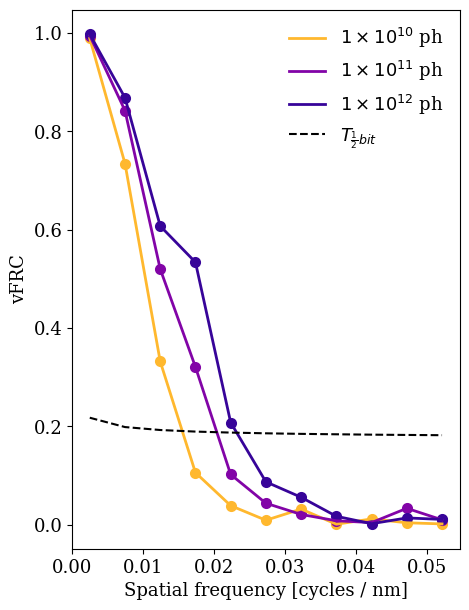

In [97]:

mpl.rcParams['font.family'] = 'Serif'
mpl.rcParams['font.size'] = 13

def half_bit_threshold(n_pixels):
    with np.errstate(divide='ignore', invalid='ignore'):
        sqrt_n = np.sqrt(n_pixels.astype(float)*2)  # Multiply by 2 to account for the two independent fields
        half_bit_threshold = np.where(
            n_pixels > 0,
            (0.2071 + 1.9102 / sqrt_n) / (1.2071 + 0.9102 / sqrt_n),
            np.nan
        )
    return half_bit_threshold

colours = [light_yellow, light_purple, dark_purple]
labels = [r"$1\times 10^{10}$ ph", r"$1\times 10^{11}$ ph", r"$1\times 10^{12}$ ph"]
seed_0_files = [
    r'.\Successfull fluence run 03_06_2026 RndSeed 0\fluence_1e10\recon_post_STXM_10.pt',
    r'.\Successfull fluence run 03_06_2026 RndSeed 0\fluence_1e11\recon_post_STXM_10.pt',
    r'.\Successfull fluence run 03_06_2026 RndSeed 0\fluence_1e12\recon_post_STXM_10.pt',
    ]

seed_5_files = [
    r'.\Successfull fluence run 04_06_2026 RndSeed 5\fluence_1e10\recon_post_STXM_10.pt',
    r'.\Successfull fluence run 04_06_2026 RndSeed 5\fluence_1e11\recon_post_STXM_10.pt',
    r'.\Successfull fluence run 04_06_2026 RndSeed 5\fluence_1e12\recon_post_STXM_10.pt',
    ]
pixel_size = 9.15  # nm
plt.figure(figsize=(5, 7))
for i in range(len(seed_0_files)):
    ckpt_rnd_seed0 = torch.load(seed_0_files[i])
    field1 = _to_numpy(ckpt_rnd_seed0['l'])

    ckpt_rnd_seed5 = torch.load(seed_5_files[i])
    field2 = _to_numpy(ckpt_rnd_seed5['l'])

    crop_size = 120
    field1 = field1[:, crop_size:-crop_size, crop_size:-crop_size]
    field2 = field2[:, crop_size:-crop_size, crop_size:-crop_size]
    print("Field shapes:", field1.shape, field2.shape)

    # Normalise to unit vectors
    field1 /= np.linalg.norm(field1, axis=0, keepdims=True)
    field2 /= np.linalg.norm(field2, axis=0, keepdims=True)

    q_bins, frc, half_bit, resolution, n_pixels = vector_frc(field1, field2, pixel_size=pixel_size, plot_diagnostics=False)
    plt.plot(q_bins, frc, color=colours[i], lw=2, label=labels[i])
    plt.scatter(q_bins, frc, color=colours[i], lw=2)

plt.plot(q_bins, half_bit_threshold(n_pixels), color='black', lw=1.5, linestyle="--", label=r"$T_{\frac{1}{2} bit}$")
print(f"Estimated resolution: {resolution:.2f} nm")
print(f"Number of pixels: {n_pixels}")

    #fig = plot_frc(q_bins, frc, half_bit, resolution, pixel_size_label="nm")
    #plt.show()


plt.xlabel(f"Spatial frequency [cycles / nm]")
plt.ylabel("vFRC")
plt.legend(frameon=False)
plt.savefig(r'.\FRC_comparison.svg', bbox_inches='tight')
plt.show()
